Adelaide Rainfall Patterns 

In [152]:
#importing libraries used
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy



Loading data in Pandas Data Frames

In [153]:
#load CSV file (1 from West Terrace )
#data frame (table data structure)
df1 = pd.read_csv("IDCJAC0009_023000_1800_Data.csv") #Read west terrace data into df1
filtered_df1 = df1[(df1['Year'] < 1979) | (df1['Year'] > 2019)] #filter out dates 1979-2019 (missing data)

df2 = pd.read_csv("IDCJAC0009_023090_1800_Data.csv") #Read Kent Town data into df2
filtered_df2 = df2[(df2['Year'] >= 1979) & (df2['Year'] <= 2019)] #use only data in dates filtered out of df1

df_combined = pd.concat([filtered_df1, filtered_df2]) #data frame for west terrace data and kent combined

#df_combined[df_combined["Rainfall amount (millimetres)"] > 0]


Here we will group the dataframe by the total rainfall by year using the pandas .groupby method. 

In [154]:
# Grouping the combined dataframe by total rainfall using pandas .groupby method into series. (Like dictionary)
yearly_rainfall = df_combined.groupby('Year')['Rainfall amount (millimetres)'].sum() #All years rainfall
ten_year_rainfall = df_combined.groupby((df_combined['Year'] // 10) * 10)['Rainfall amount (millimetres)'].sum() #Rainfall for each 10yrs

#Removing incomplete years from dataset 
yearly_rainfall = yearly_rainfall.drop([2026])
ten_year_rainfall = ten_year_rainfall.drop([1830, 2020]) #.drop a pandas method. Python list requires .remove(value) or .remove[index]

#Table for 10 year rainfall count
ten_year_rainfall.to_frame() #.to_frame is a jupyter thing 




,Rainfall amount (millimetres)
Year,
1840,5433.4
1850,5724.0
1860,5045.6
1870,5556.5
1880,5177.8
1890,4961.5
1900,5610.9
1910,5109.4
1920,5689.4


Then matplotlib library will be used to create bar graphs of this data. 

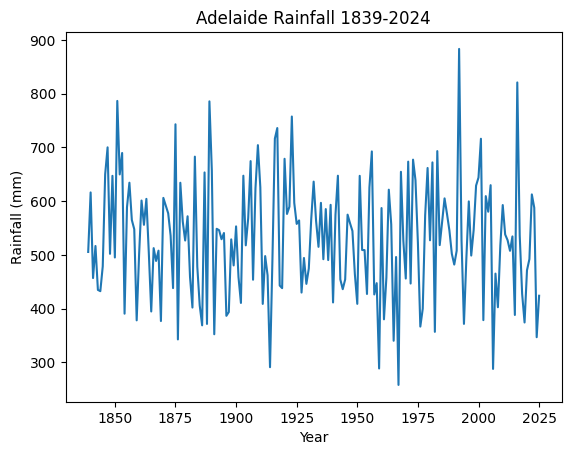

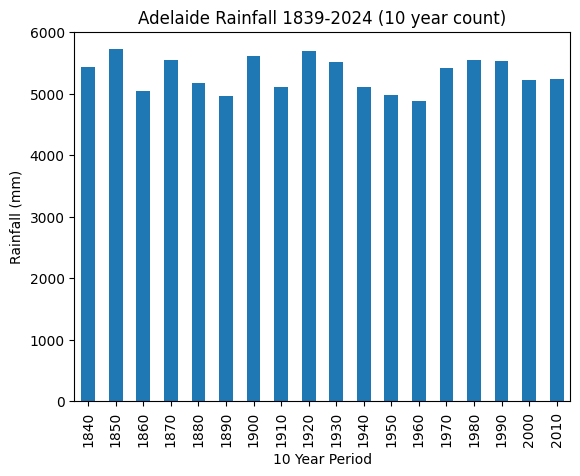

In [155]:

#All years rainfall bar graph
yearly_rainfall.plot(kind='line')
plt.title('Adelaide Rainfall 1839-2024')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.show()

#Adjusted to 10 year averages. 
ten_year_rainfall.plot(kind='bar')
plt.title('Adelaide Rainfall 1839-2024 (10 year count)')
plt.xlabel('10 Year Period')
plt.ylabel('Rainfall (mm)')
plt.show()

